In [140]:
!pip install pandas scikit-learn matplotlib seaborn joblib

In [141]:
import pandas as pd

# Download the SMS dataset

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(
url,
sep="\t",
header=None,
names=["label", "message"]
)

# Show confirmation

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Display the first five messages

df.head()


Dataset loaded successfully!
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [142]:
# Check the dataset size

print("Dataset shape:", df.shape)

# Count spam and legitimate messages

print("\nLabel counts:")
print(df["label"].value_counts())

# Check for missing values

print("\nMissing values:")
print(df.isnull().sum())

# Display the first five messages

df.head()


Dataset shape: (5572, 2)

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [143]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate messages and labels

X = df["message"]
y = df["label"]

# Split data: 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

# Convert text messages into numerical features

vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Display results

print("Data preparation completed successfully!")
print("Training messages:", X_train_tfidf.shape[0])
print("Testing messages:", X_test_tfidf.shape[0])
print("Number of text features:", X_train_tfidf.shape[1])


Data preparation completed successfully!
Training messages: 4457
Testing messages: 1115
Number of text features: 7403


In [144]:
from sklearn.naive_bayes import MultinomialNB

# Create the model

model = MultinomialNB()

# Train the model

model.fit(X_train_tfidf, y_train)

# Display confirmation

print("Model trained successfully!")
print("Algorithm: Multinomial Naive Bayes")
print("Training samples:", X_train_tfidf.shape[0])


Model trained successfully!
Algorithm: Multinomial Naive Bayes
Training samples: 4457


In [145]:
from sklearn.metrics import accuracy_score, classification_report

# Predict the labels of test messages

y_pred = model.predict(X_test_tfidf)

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 35)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Show precision, recall, and F1-score

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation Results
-----------------------------------
Accuracy: 97.04%

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



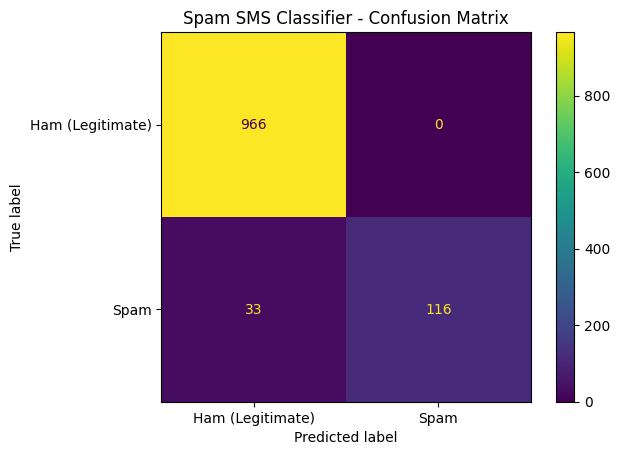

Confusion Matrix:
[[966   0]
 [ 33 116]]


In [146]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

# Create the confusion matrix display

cm_display = ConfusionMatrixDisplay(
confusion_matrix=cm,
display_labels=["Ham (Legitimate)", "Spam"]
)

# Plot the matrix

cm_display.plot(values_format="d")
plt.title("Spam SMS Classifier - Confusion Matrix")
plt.show()

# Print the matrix values

print("Confusion Matrix:")
print(cm)


In [147]:
import os
import joblib

# Create a folder for the project files

os.makedirs("spam_sms_classifier", exist_ok=True)

# Save the trained model

joblib.dump(model, "spam_sms_classifier/spam_model.pkl")

# Save the TF-IDF vectorizer

joblib.dump(vectorizer, "spam_sms_classifier/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")
print("\nFiles created:")
print("1. spam_model.pkl")
print("2. tfidf_vectorizer.pkl")


Model and vectorizer saved successfully!

Files created:
1. spam_model.pkl
2. tfidf_vectorizer.pkl


In [148]:
messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we meeting for lunch today?",
    "URGENT! Claim your cash reward now!"
]

messages_tfidf = vectorizer.transform(messages)
predictions = model.predict(messages_tfidf)

print("SMS Spam Classifier Results")
print("=" * 40)

for message, prediction in zip(messages, predictions):
    print("Message:", message)
    print("Prediction:", prediction.upper())
    print("-" * 40)

SMS Spam Classifier Results
Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM
----------------------------------------
Message: Hey, are we meeting for lunch today?
Prediction: HAM
----------------------------------------
Message: URGENT! Claim your cash reward now!
Prediction: SPAM
----------------------------------------


In [149]:
from google.colab import files
import shutil

shutil.make_archive(
    "spam_sms_classifier",
    "zip",
    "spam_sms_classifier"
)

files.download("spam_sms_classifier.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [150]:
readme_content = """
# Spam SMS Classifier

This project uses Machine Learning to classify SMS messages
as Spam or Ham (legitimate messages).

## Technologies Used
- Python
- Pandas
- Scikit-learn
- TF-IDF
- Multinomial Naive Bayes

## Model Accuracy
97.04%

## How It Works
1. Load the SMS dataset.
2. Process messages using TF-IDF.
3. Train a Naive Bayes model.
4. Evaluate the model.
5. Predict whether messages are Spam or Ham.
"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [151]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [152]:
requirements = """pandas
scikit-learn
matplotlib
seaborn
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [153]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>